1. Normalized + windowed time-series dataset
1.1. Conceptual setup (for a paper)

You have, for each experiment 
e∈{1,…,E}:

Physical model output:

𝑇𝑐(𝑒)(𝑡𝑖)𝑖=1,…,𝑛

Measured spindle current:

𝐼𝑞(𝑒)(𝑡𝑖)Iq(e)(ti)

You want to train a neural map 
𝑁𝜃:𝑥𝑖:𝑖+𝐿−1↦𝑦𝑖:𝑖+𝐿−1

↦yi:i+L−1
where
𝑥𝑖:𝑖+𝐿−1x
is a window of modeled torque (and possibly other features),
𝑦𝑖:𝑖+𝐿−1yi:i+L−1
	​
is the corresponding window of measured current,

L is the sequence length (“window size”).
This respects temporal structure, which a simple i.i.d. regression would ignore.
1.2. Normalization

For training stability, you usually normalize features to zero mean and unit variance:

𝑇~𝑐=𝑇𝑐−𝜇𝑇
𝐼~𝑞=𝐼𝑞−𝜇𝐼𝜎𝐼

Crucially, you estimate 

 on the training set only, then apply them to validation/test data.

In [1]:
def interpolate_nan(x):
    """Interpolate NaN values in a 1D array."""
    x = x.copy()
    nans = np.isnan(x)
    
    if np.all(nans):
        raise ValueError("Array contains only NaNs — cannot interpolate.")
    
    x[nans] = np.interp(
        np.flatnonzero(nans),
        np.flatnonzero(~nans),
        x[~nans]
    )
    return x


In [ ]:
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Load all measurement files ---
tool_type = 'C1030'

base = (f"../../../data/preprocessed/Mill/measurement_*_training_data.csv")
files = sorted(glob.glob(base))

all_Tc = []
all_Iq = []

for f in files:
    df = pd.read_csv(f)
    Tc = df["Tc_model"].values.astype(float)
    Iq = df["Iq_real"].values.astype(float)
    Tc_clean = interpolate_nan(Tc)
    Iq_clean = interpolate_nan(Iq)

    all_Tc.append(Tc_clean)
    all_Iq.append(Iq_clean)
## interpolate NaNs
Tc_clean = interpolate_nan(Tc)
Iq_clean = interpolate_nan(Iq)


# Concatenate all experiments (we keep separate arrays too if needed)
Tc_all = np.concatenate(all_Tc)
Iq_all = np.concatenate(all_Iq)

# --- Compute normalization on entire dataset (or better: just on training split later) ---
Tc_mean, Tc_std = Tc_all.mean(), Tc_all.std()
Iq_mean, Iq_std = Iq_all.mean(), Iq_all.std()

def normalize_Tc(x):
    return (x - Tc_mean) / Tc_std

def normalize_Iq(y):
    return (y - Iq_mean) / Iq_std

# --- Build windowed dataset ---
def build_windows(Tc_list, Iq_list, window_size=128, stride=1):
    X, Y = [], []
    for Tc, Iq in zip(Tc_list, Iq_list):
        Tc_norm = normalize_Tc(Tc)
        Iq_norm = normalize_Iq(Iq)
        n = len(Tc)
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            X.append(Tc_norm[start:end])   # (L,)
            Y.append(Iq_norm[start:end])   # (L,)
    X = np.array(X)[..., None]  # shape: (num_windows, L, 1)
    Y = np.array(Y)[..., None]  # shape: (num_windows, L, 1)
    return X, Y

X, Y = build_windows(all_Tc, all_Iq, window_size=128, stride=16)

# Train/validation split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)


In [3]:
## check if Tc and Iq have NaNs
print(f'NaNs found in X_train {np.isnan(X_train).sum()}')
print(f'NaNs found in Y_train {np.isnan(Y_train).sum()}')


NaNs found in X_train 0
NaNs found in Y_train 0


## Keras baseline model

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
features = X_train.shape[2]   # 1 in our case

def build_baseline_conv_model(timesteps, features):
    inputs = layers.Input(shape=(timesteps, features))
    
    x = layers.Conv1D(filters=32, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(filters=32, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(x)
    
    # Final layer outputs one channel (Iq prediction)
    outputs = layers.Conv1D(filters=1, kernel_size=1, padding="same", activation="linear")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

baseline_model = build_baseline_conv_model(timesteps, features)
baseline_model.summary()

history = baseline_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=64
)


2025-11-29 18:26:59.091705: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-29 18:26:59.135323: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-29 18:27:03.961787: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-11-29 18:27:04.425647: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bu

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 128, 32)           192       
                                                                 
 conv1d_1 (Conv1D)           (None, 128, 32)           5152      
                                                                 
 conv1d_2 (Conv1D)           (None, 128, 16)           2576      
                                                                 
 conv1d_3 (Conv1D)           (None, 128, 1)            17        
                                                                 
Total params: 7937 (31.00 KB)
Trainable params: 7937 (31.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/60


2025-11-29 18:27:08.252834: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-11-29 18:27:10.330346: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1b6ea600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-29 18:27:10.330400: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-11-29 18:27:10.335136: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-29 18:27:10.436865: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


421/421 [==============================] - ETA: 0s - loss: 0.8942 - mae: 0.7759

2025-11-29 18:27:14.696736: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


421/421 [==============================] - 8s 8ms/step - loss: 0.8942 - mae: 0.7759 - val_loss: 0.8725 - val_mae: 0.7660
Epoch 2/60
421/421 [==============================] - 2s 5ms/step - loss: 0.8684 - mae: 0.7613 - val_loss: 0.8581 - val_mae: 0.7579
Epoch 3/60
421/421 [==============================] - 3s 7ms/step - loss: 0.8556 - mae: 0.7537 - val_loss: 0.8500 - val_mae: 0.7471
Epoch 4/60
421/421 [==============================] - 5s 12ms/step - loss: 0.8445 - mae: 0.7465 - val_loss: 0.8487 - val_mae: 0.7507
Epoch 5/60
421/421 [==============================] - 5s 11ms/step - loss: 0.8380 - mae: 0.7423 - val_loss: 0.8286 - val_mae: 0.7368
Epoch 6/60
421/421 [==============================] - 2s 5ms/step - loss: 0.8312 - mae: 0.7380 - val_loss: 0.8233 - val_mae: 0.7356
Epoch 7/60
421/421 [==============================] - 5s 11ms/step - loss: 0.8261 - mae: 0.7352 - val_loss: 0.8226 - val_mae: 0.7318
Epoch 8/60
421/421 [==============================] - 5s 12ms/step - loss: 0.8220 - 

## Keras LSTM model

In [5]:
def build_lstm_seq2seq_model(timesteps, features, hidden_units=64):
    inputs = layers.Input(shape=(timesteps, features))

    x = layers.LSTM(hidden_units, return_sequences=True)(inputs)
    x = layers.LSTM(hidden_units, return_sequences=True)(x)
    
    # Time-distributed dense over each timestep
    outputs = layers.TimeDistributed(layers.Dense(1))(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

lstm_model = build_lstm_seq2seq_model(timesteps, features, hidden_units=128)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=32
)


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 1)]          0         
                                                                 
 lstm (LSTM)                 (None, 128, 128)          66560     
                                                                 
 lstm_1 (LSTM)               (None, 128, 128)          131584    
                                                                 
 time_distributed (TimeDist  (None, 128, 1)            129       
 ributed)                                                        
                                                                 
Total params: 198273 (774.50 KB)
Trainable params: 198273 (774.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/60
841/841 [==============================] - 22s 22ms/step - loss: 0.9065 - 

In [6]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12,5))
    
    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title("Loss During Training", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- MAE ---
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
    plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    plt.title("MAE During Training", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Mean Absolute Error", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


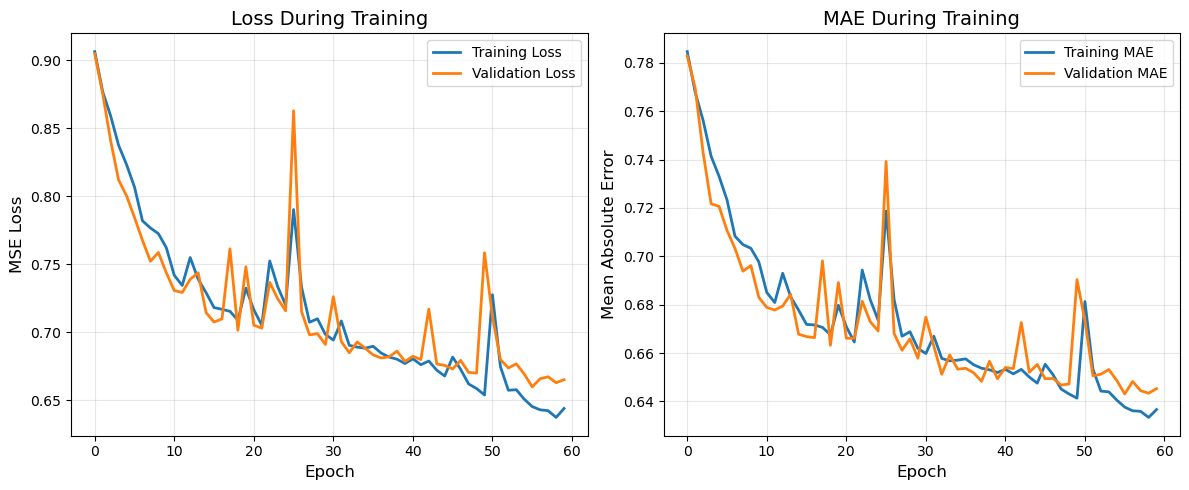

In [7]:
plot_training_history(history_lstm)

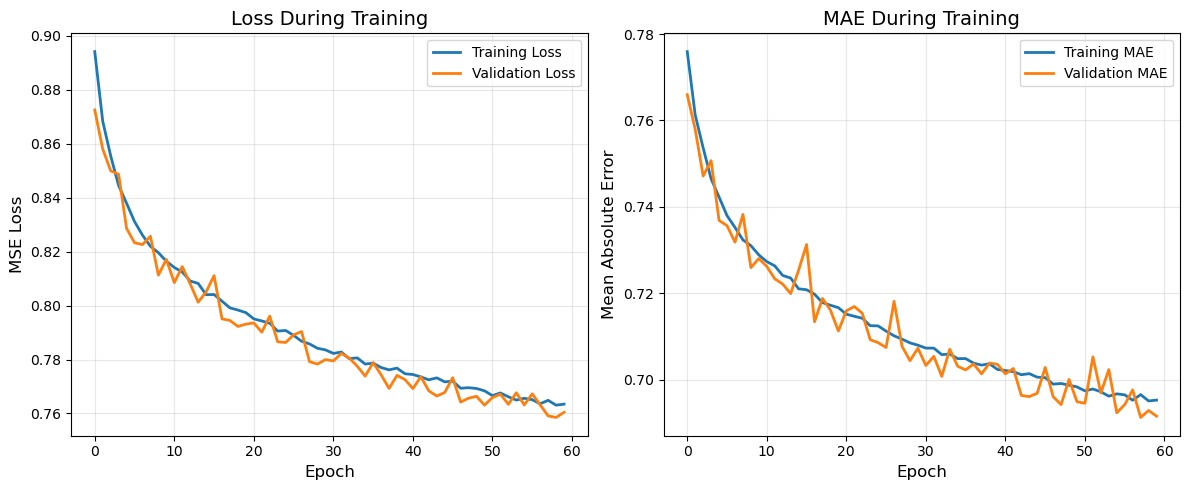

In [8]:
plot_training_history(history)

## Academic Framing


“Hyperparameters for the neural models were automatically optimized using Bayesian hyperparameter search as implemented in KerasTuner. For each model architecture (Conv1D and LSTM seq2seq), a search space was defined covering the number of layers, number of filters or hidden units, learning rate, kernel sizes, and batch size. The tuner evaluated candidate configurations on validation loss and selected the model with minimal validation MSE. This approach ensures a principled, data-driven selection of architectural and training hyperparameters, reducing manual bias and improving reproducibility.”

This is clean, correct, and academically accepted.

## Auto-tuning the Conv1D Baseline Model
Step 1 — Define a KerasTuner model builder

In [9]:
import keras_tuner as kt
from tensorflow.keras import layers, models

def build_conv_model(hp):

    timesteps = X_train.shape[1]
    features  = X_train.shape[2]

    inputs = layers.Input(shape=(timesteps, features))

    x = inputs

    # Number of CNN layers
    for i in range(hp.Int("conv_layers", min_value=1, max_value=4)):
        x = layers.Conv1D(
            filters=hp.Int(f"filters_{i}", 16, 128, step=16),
            kernel_size=hp.Choice(f"kernel_{i}", [3,5,7,9]),
            activation="relu",
            padding="same"
        )(x)

    # Output layer
    outputs = layers.Conv1D(filters=1, kernel_size=1, activation="linear")(x)

    model = models.Model(inputs, outputs)

    # Learning rate search
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model


Step 2 — Run the tuner

Bayesian optimization:

In [10]:
tuner_conv = kt.BayesianOptimization(
    build_conv_model,
    objective="val_loss",
    max_trials=25,
    overwrite=True,
    directory="tuning_results",
    project_name="conv1d_tuning"
)

tuner_conv.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=64,
    verbose=1
)


Trial 25 Complete [00h 01m 42s]
val_loss: 0.7172631621360779

Best val_loss So Far: 0.708267092704773
Total elapsed time: 00h 45m 49s
INFO:tensorflow:Oracle triggered exit


Step 3 — Retrieve the best Conv1D model

In [20]:
best_conv_model = tuner_conv.get_best_models(num_models=1)[0]
best_conv_hp = tuner_conv.get_best_hyperparameters(1)[0]

print("Best Conv1D Hyperparameters:")

for key, value in best_conv_hp.values.items():
    print(f"{key}: {value}")


Best Conv1D Hyperparameters:
conv_layers: 3
filters_0: 112
kernel_0: 9
lr: 0.004973292104754128
filters_1: 64
kernel_1: 9
filters_2: 64
kernel_2: 7
filters_3: 32
kernel_3: 5


## Auto-tuning the LSTM seq2seq Model

Same process, but tuning:

- number of LSTM layers
- units
- dropout
- learning rate

In [12]:
def build_lstm_model(hp):
    
    timesteps = X_train.shape[1]
    features  = X_train.shape[2]

    inputs = layers.Input(shape=(timesteps, features))

    x = inputs

    # Number of LSTM layers
    num_layers = hp.Int("lstm_layers", 1, 3)

    for i in range(num_layers):
        x = layers.LSTM(
            units=hp.Int(f"lstm_units_{i}", 16, 128, step=16),
            return_sequences=True,
            dropout=hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)
        )(x)

    outputs = layers.TimeDistributed(layers.Dense(1))(x)

    model = models.Model(inputs, outputs)

    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    
    return model


### Step 2 — Run the LSTM tuner

In [13]:
tuner_lstm = kt.BayesianOptimization(
    build_lstm_model,
    objective="val_loss",
    max_trials=25,
    overwrite=True,
    directory="tuning_results",
    project_name="lstm_tuning"
)

tuner_lstm.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=32,
    verbose=1
)


Trial 25 Complete [00h 15m 47s]
val_loss: 0.7128036022186279

Best val_loss So Far: 0.6552060842514038
Total elapsed time: 04h 32m 02s
INFO:tensorflow:Oracle triggered exit


### Step 3 — Fetch best LSTM model

In [16]:
best_lstm_model = tuner_lstm.get_best_models(num_models=1)[0]
best_lstm_hp = tuner_lstm.get_best_hyperparameters(1)[0]

print("Best LSTM Hyperparameters:")
for key, value in best_lstm_hp.values.items():
    print(f"{key}: {value}")



Best LSTM Hyperparameters:
lstm_layers: 3
lstm_units_0: 128
dropout_0: 0.0
lr: 0.0018937818424837106
lstm_units_1: 112
dropout_1: 0.2
lstm_units_2: 48
dropout_2: 0.1


## Evaluate Your Tuned Models

In [17]:
best_conv_model.evaluate(X_val, Y_val)
best_lstm_model.evaluate(X_val, Y_val)


211/211 [==============================] - 4s 14ms/step - loss: 0.6552 - mae: 0.6453


[0.6552060842514038, 0.6452529430389404]

Epoch 1/40
421/421 [==============================] - 7s 9ms/step - loss: 0.7099 - mae: 0.6654 - val_loss: 0.7121 - val_mae: 0.6628
Epoch 2/40
421/421 [==============================] - 3s 6ms/step - loss: 0.7105 - mae: 0.6651 - val_loss: 0.7086 - val_mae: 0.6655
Epoch 3/40
421/421 [==============================] - 3s 6ms/step - loss: 0.7090 - mae: 0.6645 - val_loss: 0.7157 - val_mae: 0.6713
Epoch 4/40
421/421 [==============================] - 3s 7ms/step - loss: 0.7091 - mae: 0.6646 - val_loss: 0.7099 - val_mae: 0.6616
Epoch 5/40
421/421 [==============================] - 3s 6ms/step - loss: 0.7069 - mae: 0.6634 - val_loss: 0.7106 - val_mae: 0.6634
Epoch 6/40
421/421 [==============================] - 2s 6ms/step - loss: 0.7085 - mae: 0.6641 - val_loss: 0.7059 - val_mae: 0.6618
Epoch 7/40
421/421 [==============================] - 3s 7ms/step - loss: 0.7070 - mae: 0.6632 - val_loss: 0.7091 - val_mae: 0.6678
Epoch 8/40
421/421 [==============================] - 3s 6ms/step - loss: 0.

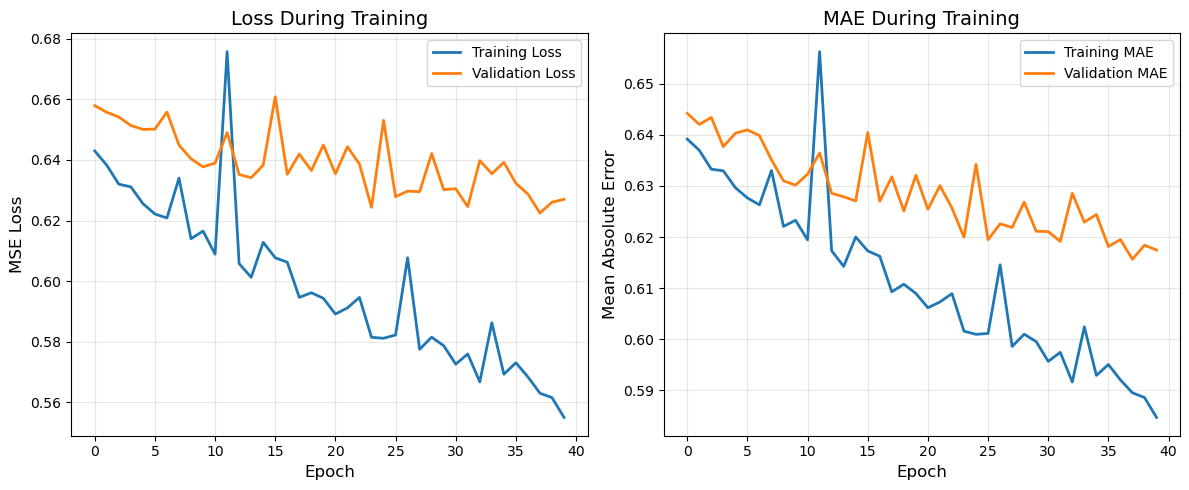

In [23]:
## best CONVd1 model
history_best_conv = best_conv_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=64
)

## best LSTM model

history_best_lstm = best_lstm_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=32
)

plot_training_history(history_best_lstm)



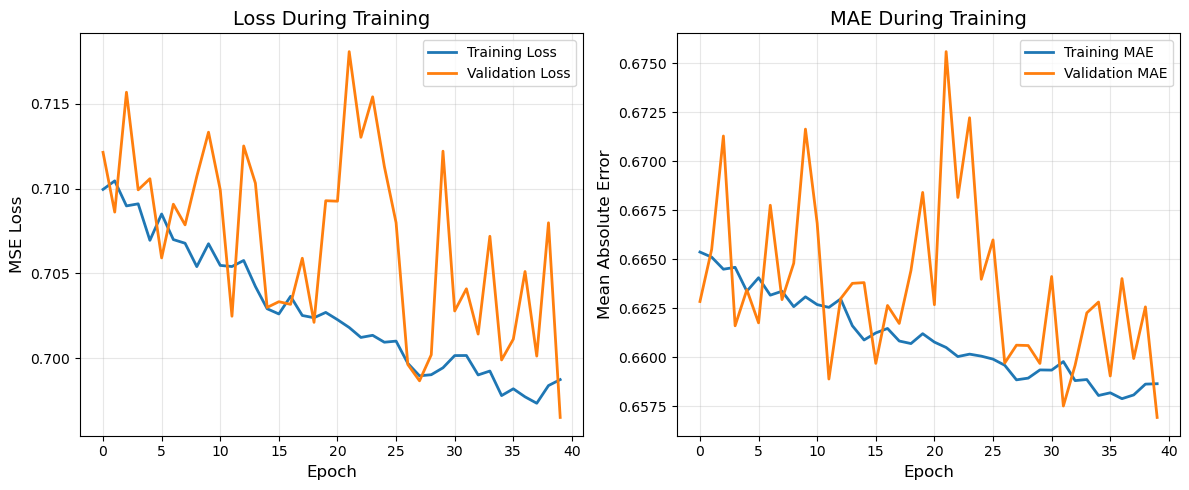

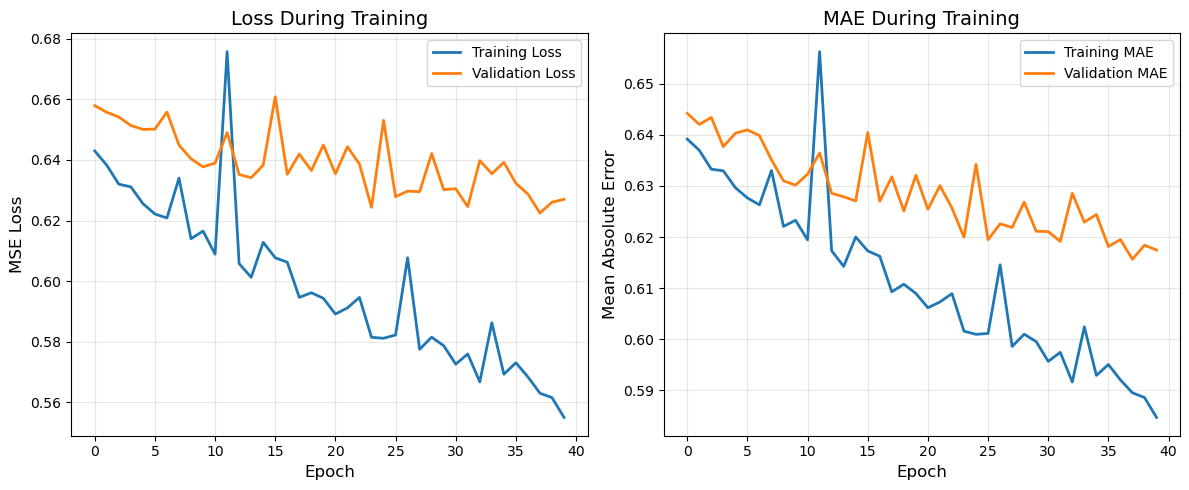

In [24]:
plot_training_history(best_conv_model.history)
plot_training_history(best_lstm_model.history)
